# 모델 2개 baseline 성능 확인

이 노트북은 현재 프로젝트의 2-stage baseline을 확인한다.

- 모델 1: `사고발생 = 위험도 > 0` 분류
- 모델 2: `위험도 > 0` 데이터만 사용한 위험도 회귀
- 학습을 자동으로 실행하지 않는다.
- 기존 metrics/predictions 산출물을 읽어 핵심 지표와 간단한 시각화를 출력한다.

In [1]:
from pathlib import Path
import os

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'streamlit_app.py').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('프로젝트 루트를 찾을 수 없습니다.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

PROJECT_ROOT = /home/huichan/SPARV/SilverWalk


In [2]:
import json
import math
import shlex
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
REPORTS_DIR = PROJECT_ROOT / 'artifacts' / 'reports'
PREDICTIONS_DIR = PROJECT_ROOT / 'artifacts' / 'predictions'
MODELS_DIR = PROJECT_ROOT / 'artifacts' / 'models'

classifier_metrics_path = REPORTS_DIR / 'mlp_accident_classifier_notebook_metrics.json'
classifier_predictions_path = PREDICTIONS_DIR / 'mlp_accident_classifier_notebook_test_predictions.csv'
classifier_history_path = REPORTS_DIR / 'mlp_accident_classifier_notebook_history.csv'

regressor_metrics_path = REPORTS_DIR / 'mlp_positive_risk_regressor_notebook_metrics.json'
regressor_predictions_path = PREDICTIONS_DIR / 'mlp_positive_risk_regressor_notebook_test_predictions.csv'
regressor_history_path = REPORTS_DIR / 'mlp_positive_risk_regressor_notebook_history.csv'

paths = [
    ('model1 metrics', classifier_metrics_path),
    ('model1 predictions', classifier_predictions_path),
    ('model1 history', classifier_history_path),
    ('model2 metrics', regressor_metrics_path),
    ('model2 predictions', regressor_predictions_path),
    ('model2 history', regressor_history_path),
]
file_status = pd.DataFrame([
    {'구분': name, '경로': path.relative_to(PROJECT_ROOT), '존재': path.exists()} for name, path in paths
])
display(file_status)

,구분,경로,존재
0,model1 metrics,artifacts/reports/mlp_accident_classifier_note...,True
1,model1 predictions,artifacts/predictions/mlp_accident_classifier_...,True
2,model1 history,artifacts/reports/mlp_accident_classifier_note...,True
3,model2 metrics,artifacts/reports/mlp_positive_risk_regressor_...,True
4,model2 predictions,artifacts/predictions/mlp_positive_risk_regres...,True
5,model2 history,artifacts/reports/mlp_positive_risk_regressor_...,True


## 선택 실행: 모델 1/모델 2 학습

아래 셀은 기본적으로 학습을 실행하지 않는다. 새 산출물이 필요하면 `RUN_TRAINING = True`로 바꾼 뒤 실행한다.

In [4]:
RUN_TRAINING = True

train_model1_command = [
    'python', 'scripts/train/train_accident_classifier.py',
    '--epochs', '100',
    '--batch-size', '1024',
    '--device', 'auto',
    '--verbose', '2',
    '--threshold', '0.5',
    '--model-path', str(MODELS_DIR / 'mlp_accident_classifier_notebook.keras'),
    '--metrics-path', str(classifier_metrics_path),
    '--history-path', str(classifier_history_path),
    '--predictions-path', str(classifier_predictions_path),
    '--top-k', '100', '300', '500', '700', '1000',
]
train_model2_command = [
    'python', 'scripts/train/train_positive_risk_regressor.py',
    '--epochs', '100',
    '--batch-size', '1024',
    '--device', 'auto',
    '--verbose', '2',
    '--model-path', str(MODELS_DIR / 'mlp_positive_risk_regressor_notebook.keras'),
    '--metrics-path', str(regressor_metrics_path),
    '--history-path', str(regressor_history_path),
    '--predictions-path', str(regressor_predictions_path),
]

print('모델 1 실행 명령:')
print(shlex.join(train_model1_command))
print('\n모델 2 실행 명령:')
print(shlex.join(train_model2_command))

if RUN_TRAINING:
    subprocess.run(train_model1_command, cwd=PROJECT_ROOT, check=True)
    subprocess.run(train_model2_command, cwd=PROJECT_ROOT, check=True)
else:
    print('RUN_TRAINING=False 이므로 학습을 실행하지 않았습니다.')

모델 1 실행 명령:
python scripts/train/train_accident_classifier.py --epochs 100 --batch-size 1024 --device auto --verbose 2 --threshold 0.5 --model-path /home/huichan/SPARV/SilverWalk/artifacts/models/mlp_accident_classifier_notebook.keras --metrics-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_accident_classifier_notebook_metrics.json --history-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_accident_classifier_notebook_history.csv --predictions-path /home/huichan/SPARV/SilverWalk/artifacts/predictions/mlp_accident_classifier_notebook_test_predictions.csv --top-k 100 300 500 700 1000

모델 2 실행 명령:
python scripts/train/train_positive_risk_regressor.py --epochs 100 --batch-size 1024 --device auto --verbose 2 --model-path /home/huichan/SPARV/SilverWalk/artifacts/models/mlp_positive_risk_regressor_notebook.keras --metrics-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_positive_risk_regressor_notebook_metrics.json --history-path /home/huichan/SPARV/SilverWalk/art

I0000 00:00:1780776425.793178  362137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780776425.845731  362137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780776426.691033  362137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780776427.473631  362137 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please mak

Epoch 1/100
309/309 - 2s - 7ms/step - accuracy: 0.8000 - loss: 0.4479 - pr_auc: 0.4021 - precision: 0.4969 - recall: 0.2304 - roc_auc: 0.7382 - val_accuracy: 0.8197 - val_loss: 0.4128 - val_pr_auc: 0.4958 - val_precision: 0.6551 - val_recall: 0.2025 - val_roc_auc: 0.7823 - learning_rate: 0.0010
Epoch 2/100
309/309 - 1s - 4ms/step - accuracy: 0.8185 - loss: 0.4154 - pr_auc: 0.4882 - precision: 0.6137 - recall: 0.2429 - roc_auc: 0.7778 - val_accuracy: 0.8239 - val_loss: 0.4033 - val_pr_auc: 0.5182 - val_precision: 0.6678 - val_recall: 0.2331 - val_roc_auc: 0.7957 - learning_rate: 0.0010
Epoch 3/100
309/309 - 1s - 4ms/step - accuracy: 0.8208 - loss: 0.4072 - pr_auc: 0.5056 - precision: 0.6205 - recall: 0.2608 - roc_auc: 0.7902 - val_accuracy: 0.8276 - val_loss: 0.3946 - val_pr_auc: 0.5375 - val_precision: 0.6910 - val_recall: 0.2448 - val_roc_auc: 0.8084 - learning_rate: 0.0010
Epoch 4/100
309/309 - 1s - 4ms/step - accuracy: 0.8240 - loss: 0.4004 - pr_auc: 0.5222 - precision: 0.6333 - rec

I0000 00:00:1780776563.469830  367099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780776563.544543  367099 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780776564.404408  367099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780776565.190181  367099 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please mak

Epoch 1/100
62/62 - 1s - 17ms/step - loss: 0.5410 - mae: 0.9123 - rmse: 1.2490 - val_loss: 0.3207 - val_mae: 0.6474 - val_rmse: 0.9174 - learning_rate: 0.0010
Epoch 2/100
62/62 - 0s - 6ms/step - loss: 0.3213 - mae: 0.6576 - rmse: 0.8895 - val_loss: 0.2856 - val_mae: 0.6064 - val_rmse: 0.8386 - learning_rate: 0.0010
Epoch 3/100
62/62 - 0s - 5ms/step - loss: 0.3026 - mae: 0.6326 - rmse: 0.8590 - val_loss: 0.2760 - val_mae: 0.5979 - val_rmse: 0.8126 - learning_rate: 0.0010
Epoch 4/100
62/62 - 0s - 5ms/step - loss: 0.2912 - mae: 0.6173 - rmse: 0.8400 - val_loss: 0.2696 - val_mae: 0.5898 - val_rmse: 0.8014 - learning_rate: 0.0010
Epoch 5/100
62/62 - 0s - 5ms/step - loss: 0.2841 - mae: 0.6085 - rmse: 0.8284 - val_loss: 0.2638 - val_mae: 0.5826 - val_rmse: 0.7892 - learning_rate: 0.0010
Epoch 6/100
62/62 - 0s - 5ms/step - loss: 0.2778 - mae: 0.5995 - rmse: 0.8174 - val_loss: 0.2596 - val_mae: 0.5780 - val_rmse: 0.7823 - learning_rate: 0.0010
Epoch 7/100
62/62 - 0s - 5ms/step - loss: 0.2726 - 

In [5]:
required_paths = [classifier_metrics_path, classifier_predictions_path, regressor_metrics_path, regressor_predictions_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = '\n'.join(str(path.relative_to(PROJECT_ROOT)) for path in missing_paths)
    raise FileNotFoundError(f'필수 산출물이 없습니다. 먼저 학습을 실행하십시오.\n{missing_text}')

with classifier_metrics_path.open('r', encoding='utf-8') as file:
    classifier_metrics = json.load(file)
with regressor_metrics_path.open('r', encoding='utf-8') as file:
    regressor_metrics = json.load(file)

classifier_predictions = pd.read_csv(classifier_predictions_path)
regressor_predictions = pd.read_csv(regressor_predictions_path)

print(f'model1 rows: {len(classifier_predictions):,}')
print(f'model2 rows: {len(regressor_predictions):,}')
display(classifier_predictions.head())
display(regressor_predictions.head())

model1 rows: 67,600
model2 rows: 13,482


,POINT_ID,위도,경도,위험도,사고발생,사고발생확률,사고발생예측
0,1,37.5910,126.9926,0.0000,0,0.0050,0
1,8,37.5901,126.9918,0.0000,0,0.0085,0
2,9,37.5902,126.9916,0.0000,0,0.0071,0
3,25,37.5833,127.0001,0.0000,0,0.0156,0
4,29,37.5828,126.9991,37.0080,1,0.6358,1


,POINT_ID,위도,경도,위험도,위험도_log1p,pred_위험도_log1p,pred_위험도
0,29,37.5828,126.9991,37.0080,3.6378,3.4265,29.7688
1,31,37.5720,126.9917,5.4880,1.8700,1.3463,2.8431
2,33,37.5720,126.9920,0.2720,0.2406,0.7144,1.0431
3,41,37.5737,127.0103,9.8880,2.3877,1.6985,4.4656
4,42,37.5737,127.0101,1.1680,0.7738,1.3815,2.9808


In [6]:
def precision_recall_at_top_percent(y_true, score, top_percent=0.10):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    k = max(1, math.ceil(len(score) * top_percent))
    order = np.argsort(-score, kind='mergesort')[:k]
    hits = int(y_true[order].sum())
    positives = int(y_true.sum())
    return {
        'top_percent': top_percent,
        'k': k,
        'hit_count': hits,
        'precision': hits / k,
        'recall': hits / positives if positives else np.nan,
    }

y_true_model1 = classifier_predictions['사고발생'].to_numpy(dtype=int)
score_model1 = classifier_predictions['사고발생확률'].to_numpy(dtype=float)
pred_model1 = classifier_predictions['사고발생예측'].to_numpy(dtype=int)
model1_top10 = precision_recall_at_top_percent(y_true_model1, score_model1, top_percent=0.10)

model1_summary = pd.DataFrame([{
    'experiment': 'two_stage_baseline_model1',
    'pr_auc': average_precision_score(y_true_model1, score_model1),
    'f1': f1_score(y_true_model1, pred_model1, zero_division=0),
    'precision@top10%': model1_top10['precision'],
    'recall@top10%': model1_top10['recall'],
    'top10_k': model1_top10['k'],
}])

actual_risk_model2 = regressor_predictions['위험도'].to_numpy(dtype=float)
pred_risk_model2 = regressor_predictions['pred_위험도'].to_numpy(dtype=float)
model2_summary = pd.DataFrame([{
    'experiment': 'two_stage_baseline_model2',
    'mae': regressor_metrics.get('risk_scale', {}).get('mae', mean_absolute_error(actual_risk_model2, pred_risk_model2)),
    'rmse': regressor_metrics.get('risk_scale', {}).get('rmse', math.sqrt(mean_squared_error(actual_risk_model2, pred_risk_model2))),
    'log_mae': regressor_metrics.get('log_scale', {}).get('mae', np.nan),
    'log_rmse': regressor_metrics.get('log_scale', {}).get('rmse', np.nan),
}])

display(model1_summary)
display(model2_summary)

,experiment,pr_auc,f1,precision@top10%,recall@top10%,top10_k
0,two_stage_baseline_model1,0.7412,0.6176,0.8229,0.4126,6760


,experiment,mae,rmse,log_mae,log_rmse
0,two_stage_baseline_model2,1.9528,5.9006,0.3957,0.5497


/tmp/ipykernel_361540/103051713.py:15: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_361540/103051713.py:15: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_361540/103051713.py:15: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph

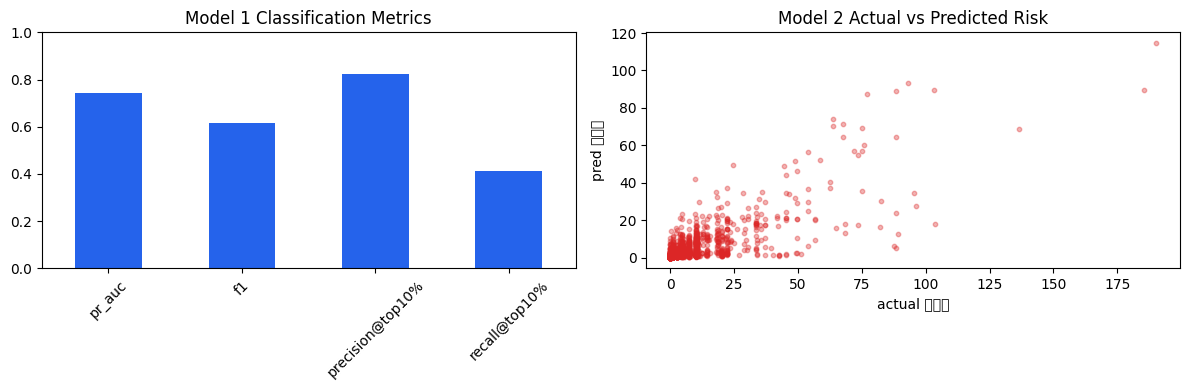

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model1_plot = model1_summary.set_index('experiment')[['pr_auc', 'f1', 'precision@top10%', 'recall@top10%']].T
model1_plot.plot(kind='bar', ax=axes[0], legend=False, color='#2563eb')
axes[0].set_ylim(0, 1)
axes[0].set_title('Model 1 Classification Metrics')
axes[0].tick_params(axis='x', rotation=45)

sample = regressor_predictions.sample(min(len(regressor_predictions), 5000), random_state=42)
axes[1].scatter(sample['위험도'], sample['pred_위험도'], s=10, alpha=0.35, color='#dc2626')
axes[1].set_title('Model 2 Actual vs Predicted Risk')
axes[1].set_xlabel('actual 위험도')
axes[1].set_ylabel('pred 위험도')

plt.tight_layout()
plt.show()

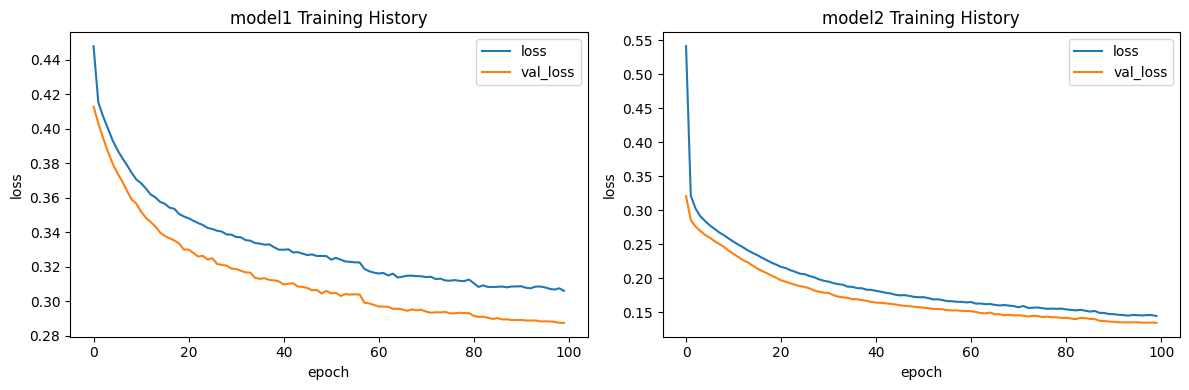

In [8]:
history_paths = [
    ('model1', classifier_history_path),
    ('model2', regressor_history_path),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (name, path) in zip(axes, history_paths):
    if not path.exists():
        axis.set_title(f'{name}: history 없음')
        axis.axis('off')
        continue
    history = pd.read_csv(path)
    loss_columns = [column for column in ['loss', 'val_loss'] if column in history.columns]
    if loss_columns:
        history[loss_columns].plot(ax=axis)
        axis.set_title(f'{name} Training History')
        axis.set_xlabel('epoch')
        axis.set_ylabel('loss')
    else:
        axis.set_title(f'{name}: loss 컬럼 없음')
        axis.axis('off')

plt.tight_layout()
plt.show()